<a href="https://colab.research.google.com/github/Mithiles-19/OIBSIP/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Load Dataset

In [ ]:
df = pd.read_csv("/content/ifood_df.csv")
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


Data Cleaning

In [ ]:
# Check missing values
df.isnull().sum()

# Drop duplicates
df = df.drop_duplicates()

# Fill missing values (example)
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
Feature Selection for Segmentation

In [ ]:
features = df[['Income', 'Recency', 'NumWebPurchases',
               'NumStorePurchases', 'NumCatalogPurchases',
               'NumWebVisitsMonth']]

features.head()

,Income,Recency,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth
0,58138.0,58,8,4,10,7
1,46344.0,38,1,2,1,5
2,71613.0,26,8,10,2,4
3,26646.0,26,2,4,0,6
4,58293.0,94,5,6,3,5


Feature Scaling

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Find Optimal Clusters (Elbow Method)

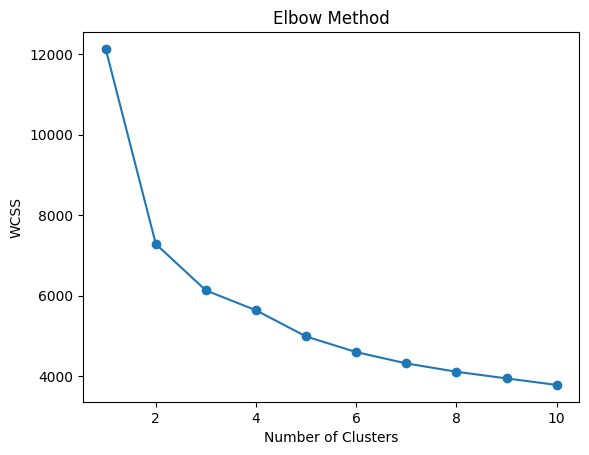

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


Apply K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Segment'] = kmeans.fit_predict(scaled_features)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Segment
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,3
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,2
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,3


Code for Each Customer Segment

In [ ]:
segment_1 = df[df['Segment'] == 1]

segment_1.describe()


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Segment
count,469.000000,469.000000,469.000000,469.000000,469.000000,469.000000,469.000000,469.000000,469.000000,469.00000,...,469.000000,469.000000,469.0,469.000000,469.000000,469.000000,469.000000,469.000000,469.000000,469.0
mean,75754.415778,0.023454,0.243070,48.486141,575.712154,60.345416,432.304904,89.918977,63.780384,72.28145,...,0.042644,0.078891,0.0,0.543710,0.170576,0.206823,1222.061834,1149.780384,0.637527,1.0
std,10290.913191,0.151502,0.444073,27.522763,310.658909,49.489316,254.060997,65.813887,50.909975,60.91936,...,0.202269,0.269857,0.0,0.498618,0.376539,0.405460,467.650998,467.972606,0.993977,0.0
min,2447.000000,0.000000,0.000000,0.000000,1.000000,0.000000,29.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,180.000000,175.000000,0.000000,1.0
25%,69755.000000,0.000000,0.000000,27.000000,336.000000,23.000000,217.000000,36.000000,24.000000,27.00000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,888.000000,802.000000,0.000000,1.0
50%,76467.000000,0.000000,0.000000,49.000000,533.000000,44.000000,408.000000,73.000000,48.000000,53.00000,...,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,1182.000000,1097.000000,0.000000,1.0
75%,82224.000000,0.000000,0.000000,72.000000,770.000000,90.000000,602.000000,138.000000,93.000000,107.00000,...,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,1554.000000,1498.000000,1.000000,1.0
max,105471.000000,1.000000,2.000000,99.000000,1493.000000,197.000000,1725.000000,254.000000,198.000000,249.00000,...,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000,1.0


In [ ]:
segment_2 = df[df['Segment'] == 2]

segment_2.describe()


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Segment
count,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,...,329.000000,329.000000,329.0,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.0
mean,59207.416413,0.270517,0.747720,21.981763,472.088146,30.972644,172.784195,38.978723,28.480243,63.112462,...,0.045593,0.088146,0.0,0.498480,0.164134,0.249240,743.303951,680.191489,0.367781,2.0
std,12078.756666,0.458404,0.512231,14.433816,301.194383,40.412007,149.641886,49.222704,38.748805,56.630511,...,0.208918,0.283939,0.0,0.500759,0.370961,0.433232,416.456062,412.548434,0.690746,0.0
min,4428.000000,0.000000,0.000000,0.000000,6.000000,0.000000,3.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,38.000000,-283.000000,0.000000,2.0
25%,51039.000000,0.000000,0.000000,9.000000,235.000000,5.000000,71.000000,6.000000,3.000000,23.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,390.000000,358.000000,0.000000,2.0
50%,59184.000000,0.000000,1.000000,22.000000,392.000000,14.000000,132.000000,19.000000,13.000000,42.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,652.000000,578.000000,0.000000,2.0
75%,67272.000000,1.000000,1.000000,34.000000,652.000000,43.000000,223.000000,56.000000,38.000000,91.000000,...,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,1011.000000,925.000000,1.000000,2.0
max,113734.000000,2.000000,2.000000,53.000000,1462.000000,199.000000,925.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,2092.000000,2092.000000,4.000000,2.0


In [ ]:
segment_3 = df[df['Segment'] == 3]

segment_3.describe()


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Segment
count,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,...,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.0
mean,58756.831395,0.267442,0.781977,76.110465,475.854651,31.395349,168.953488,43.674419,33.726744,59.744186,...,0.037791,0.063953,0.002907,0.485465,0.177326,0.270349,753.604651,693.860465,0.331395,3.0
std,11949.117950,0.468841,0.541697,14.629118,323.523444,38.080176,150.817377,54.482606,43.823337,51.870311,...,0.190967,0.245026,0.053916,0.500517,0.382500,0.444787,450.600882,439.964448,0.657367,0.0
min,7144.000000,0.000000,0.000000,46.000000,33.000000,0.000000,7.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,120.000000,-166.000000,0.000000,3.0
25%,51456.750000,0.000000,0.000000,64.000000,205.750000,5.000000,66.000000,7.000000,5.000000,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,387.750000,334.750000,0.000000,3.0
50%,58319.000000,0.000000,1.000000,76.500000,386.500000,15.000000,122.500000,20.000000,14.000000,43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,659.500000,588.000000,0.000000,3.0
75%,65815.250000,1.000000,1.000000,89.250000,650.750000,45.250000,217.250000,60.000000,45.250000,83.250000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1027.500000,975.250000,0.000000,3.0
max,94871.000000,2.000000,2.000000,99.000000,1486.000000,184.000000,780.000000,258.000000,195.000000,291.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2262.000000,2084.000000,4.000000,3.0


Visualization of Segments

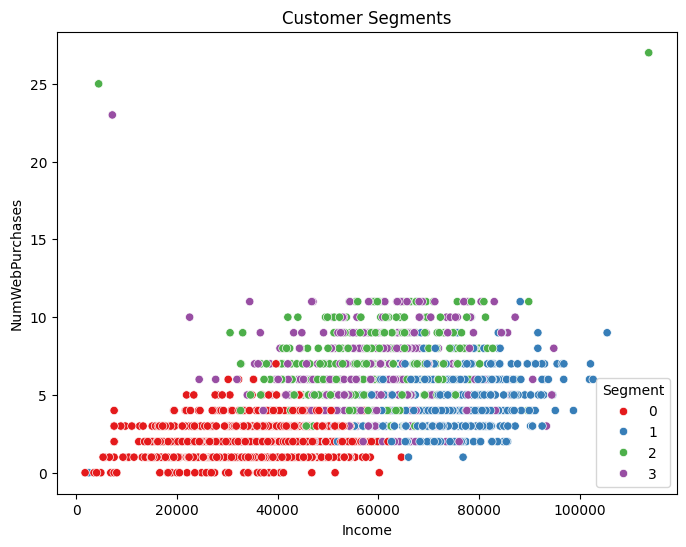

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Income'],
    y=df['NumWebPurchases'],
    hue=df['Segment'],
    palette='Set1'
)
plt.title("Customer Segments")
plt.show()


In [ ]:
segment_summary = df.groupby('Segment').mean()

segment_summary


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
Segment,,,,,,,,,,,,,,,,,,,,,
0,33264.549488,0.800910,0.456200,48.502844,34.585893,4.540387,20.352673,6.799772,4.806598,15.415245,...,0.252560,0.025028,0.108077,0.054608,0.488055,0.159272,0.189989,71.085324,55.670080,0.087600
1,75754.415778,0.023454,0.243070,48.486141,575.712154,60.345416,432.304904,89.918977,63.780384,72.281450,...,0.253731,0.042644,0.078891,0.000000,0.543710,0.170576,0.206823,1222.061834,1149.780384,0.637527
2,59207.416413,0.270517,0.747720,21.981763,472.088146,30.972644,172.784195,38.978723,28.480243,63.112462,...,0.270517,0.045593,0.088146,0.000000,0.498480,0.164134,0.249240,743.303951,680.191489,0.367781
3,58756.831395,0.267442,0.781977,76.110465,475.854651,31.395349,168.953488,43.674419,33.726744,59.744186,...,0.229651,0.037791,0.063953,0.002907,0.485465,0.177326,0.270349,753.604651,693.860465,0.331395
